<a href="https://colab.research.google.com/github/Kamali1265/ML-Ops-Tasks/blob/main/DAY-5/Smart_Factory_Machinery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SIMPLE LINEAR REGRESSION**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
df = pd.read_csv("smart_factory_machinery.csv")

df.head()

,RPM,Vibration,Pressure,Machine_Mode,Temperature,Defective
0,1200,1.2,25,Eco,45,0
1,1500,1.5,28,Eco,48,0
2,1800,1.8,30,Standard,52,0
3,2000,2.0,32,Standard,55,0
4,2200,2.1,34,Standard,58,0


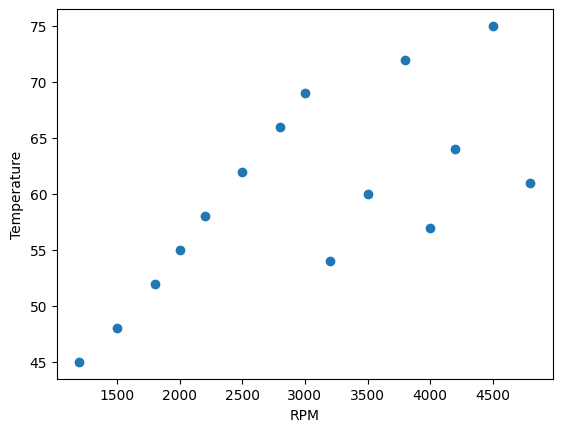

In [ ]:
plt.scatter(df['RPM'],df['Temperature'])
plt.xlabel("RPM")
plt.ylabel("Temperature")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
X = df[['RPM']]
y = df['Temperature']

In [ ]:
model.fit(X,y)

LinearRegression()

In [ ]:
model.predict([[3000]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([59.86666667])

In [ ]:
from sklearn.metrics import mean_squared_error

predictions = model.predict(X)

mse = mean_squared_error(y,predictions)

mse

34.691891146225245

**MULTIVARIATE REGRESSION**

In [ ]:
X = df[['RPM','Vibration','Pressure']]

y = df['Temperature']

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X,y)

LinearRegression()

In [ ]:
model.predict([[3000,2.8,40]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([62.52611147])

In [ ]:
predictions = model.predict(X)

mse = mean_squared_error(y,predictions)

mse

29.078830063178078

**PICKLE**

In [ ]:
import pickle

In [ ]:
with open('factory_pickle','wb') as file:
    pickle.dump(model,file)

In [ ]:
with open('factory_pickle','rb') as file:
    mp = pickle.load(file)

In [ ]:
mp.predict([[3000,2.8,40]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([62.52611147])

**JOBLIB**

In [ ]:
import joblib

In [ ]:
joblib.dump(model,'factory_joblib')

['factory_joblib']

In [ ]:
mj = joblib.load('factory_joblib')

In [ ]:
mj.predict([[3000,2.8,40]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([62.52611147])

**ONE HOT ENCODING**

In [ ]:
df = pd.read_csv("smart_factory_machinery.csv")

df

,RPM,Vibration,Pressure,Machine_Mode,Temperature,Defective
0,1200,1.2,25,Eco,45,0
1,1500,1.5,28,Eco,48,0
2,1800,1.8,30,Standard,52,0
3,2000,2.0,32,Standard,55,0
4,2200,2.1,34,Standard,58,0
5,2500,2.4,36,High-Speed,62,1
6,2800,2.6,38,High-Speed,66,1
7,3000,2.8,40,High-Speed,69,1
8,3200,3.0,42,Eco,54,0
9,3500,3.2,45,Standard,60,0


In [ ]:
dummies = pd.get_dummies(df['Machine_Mode'])

dummies

,Eco,High-Speed,Standard
0,True,False,False
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
5,False,True,False
6,False,True,False
7,False,True,False
8,True,False,False
9,False,False,True


In [ ]:
merged = pd.concat(
    [df,dummies],
    axis='columns'
)

merged

,RPM,Vibration,Pressure,Machine_Mode,Temperature,Defective,Eco,High-Speed,Standard
0,1200,1.2,25,Eco,45,0,True,False,False
1,1500,1.5,28,Eco,48,0,True,False,False
2,1800,1.8,30,Standard,52,0,False,False,True
3,2000,2.0,32,Standard,55,0,False,False,True
4,2200,2.1,34,Standard,58,0,False,False,True
5,2500,2.4,36,High-Speed,62,1,False,True,False
6,2800,2.6,38,High-Speed,66,1,False,True,False
7,3000,2.8,40,High-Speed,69,1,False,True,False
8,3200,3.0,42,Eco,54,0,True,False,False
9,3500,3.2,45,Standard,60,0,False,False,True


In [ ]:
final = merged.drop(
    ['Machine_Mode','High-Speed'],
    axis='columns'
)

final

,RPM,Vibration,Pressure,Temperature,Defective,Eco,Standard
0,1200,1.2,25,45,0,True,False
1,1500,1.5,28,48,0,True,False
2,1800,1.8,30,52,0,False,True
3,2000,2.0,32,55,0,False,True
4,2200,2.1,34,58,0,False,True
5,2500,2.4,36,62,1,False,False
6,2800,2.6,38,66,1,False,False
7,3000,2.8,40,69,1,False,False
8,3200,3.0,42,54,0,True,False
9,3500,3.2,45,60,0,False,True


**TRAIN TEST SPLIT**

In [ ]:
X = final.drop(
    ['Temperature','Defective'],
    axis='columns'
)

X

,RPM,Vibration,Pressure,Eco,Standard
0,1200,1.2,25,True,False
1,1500,1.5,28,True,False
2,1800,1.8,30,False,True
3,2000,2.0,32,False,True
4,2200,2.1,34,False,True
5,2500,2.4,36,False,False
6,2800,2.6,38,False,False
7,3000,2.8,40,False,False
8,3200,3.0,42,True,False
9,3500,3.2,45,False,True


In [ ]:
y = final['Temperature']

y

,Temperature
0,45
1,48
2,52
3,55
4,58
5,62
6,66
7,69
8,54
9,60


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

In [ ]:
X_train

,RPM,Vibration,Pressure,Eco,Standard
6,2800,2.6,38,False,False
8,3200,3.0,42,True,False
2,1800,1.8,30,False,True
10,3800,3.5,47,False,False
5,2500,2.4,36,False,False
11,4000,3.7,49,True,False
14,4800,4.4,58,True,False
1,1500,1.5,28,True,False
0,1200,1.2,25,True,False
4,2200,2.1,34,False,True


In [ ]:
X_test

,RPM,Vibration,Pressure,Eco,Standard
3,2000,2.0,32,False,True
7,3000,2.8,40,False,False
12,4200,3.9,52,False,True


In [ ]:
y_train

,Temperature
6,66
8,54
2,52
10,72
5,62
11,57
14,61
1,48
0,45
4,58


In [ ]:
y_test

,Temperature
3,55
7,69
12,64


In [ ]:
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [ ]:
model.score(X_test,y_test)

0.9109804583013292

**LOGISTIC REGRESSION**

In [ ]:
X = final.drop(
    ['Temperature','Defective'],
    axis='columns'
)

y = final['Defective']

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_predicted = model.predict(X_test)

y_predicted

array([0, 1, 1])

In [ ]:
model.predict_proba(X_test)

array([[0.86358164, 0.13641836],
       [0.4882591 , 0.5117409 ],
       [0.3375077 , 0.6624923 ]])

In [ ]:
model.score(X_test,y_test)

1.0

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_predicted
)

cm

array([[1, 0],
       [0, 2]])

<Axes: >

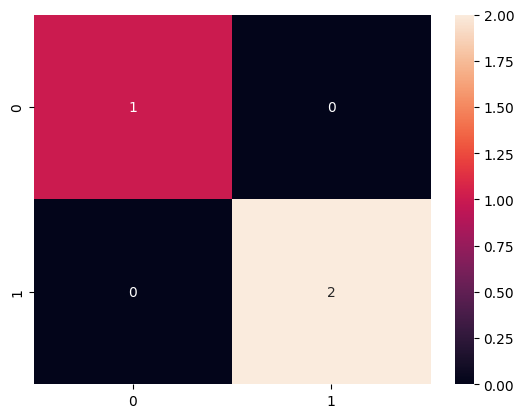

In [ ]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True
)